In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("Set2")

print("✅ Libraries imported!")

✅ Libraries imported!


In [3]:
# Load the data
df = pd.read_csv('data/insurance_data.csv')

print("="*60)
print("INSURANCE DATA LOADED")
print("="*60)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
df.head()

INSURANCE DATA LOADED
Shape: 10000 rows, 21 columns

First 5 rows:


,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [4]:
# Check data types and missing values
print("="*60)
print("DATA INFORMATION")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

DATA INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  str    
 3   Province             10000 non-null  str    
 4   VehicleType          10000 non-null  str    
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-

In [5]:
# Calculate Loss Ratio and Margin
# Loss Ratio = TotalClaims / TotalPremium
# Margin = TotalPremium - TotalClaims

df['Loss_Ratio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

print("="*60)
print("KEY INSURANCE METRICS CALCULATED")
print("="*60)
print(f"Loss Ratio - Mean: {df['Loss_Ratio'].mean():.4f}")
print(f"Loss Ratio - Median: {df['Loss_Ratio'].median():.4f}")
print(f"Margin - Mean: {df['Margin'].mean():.2f}")
print(f"Margin - Median: {df['Margin'].median():.2f}")
print(f"Margin - Total: {df['Margin'].sum():.2f}")

KEY INSURANCE METRICS CALCULATED
Loss Ratio - Mean: 0.4428
Loss Ratio - Median: 0.0000
Margin - Mean: 1173.94
Margin - Median: 2165.00
Margin - Total: 11739394.00


In [6]:
# Descriptive statistics for numerical columns
numeric_cols = ['TotalPremium', 'TotalClaims', 'Loss_Ratio', 'Margin']

print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
print(df[numeric_cols].describe())

DESCRIPTIVE STATISTICS
       TotalPremium   TotalClaims    Loss_Ratio        Margin
count  10000.000000  10000.000000  10000.000000  10000.000000
mean    2488.127900   1314.188500      0.442770   1173.939400
std      735.674491   3921.864903      1.252813   3742.979999
min      951.000000      0.000000      0.000000 -44594.000000
25%     2028.000000      0.000000      0.000000   1812.000000
50%     2307.000000      0.000000      0.000000   2165.000000
75%     2676.000000      0.000000      0.000000   2504.250000
max     5105.000000  49623.000000     15.895383   5079.000000


In [7]:
# Check categorical columns
categorical_cols = ['Province', 'Gender', 'VehicleType', 'CoverType', 'Make', 'Model']

print("="*60)
print("CATEGORICAL COLUMNS - UNIQUE VALUES")
print("="*60)
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}: {df[col].nunique()} unique values")
        print(f"  Values: {df[col].unique()[:5]}...")

CATEGORICAL COLUMNS - UNIQUE VALUES

Province: 5 unique values
  Values: <StringArray>
['Addis Ababa', 'Oromia', 'Somali', 'Tigray', 'Amhara']
Length: 5, dtype: str...

Gender: 2 unique values
  Values: <StringArray>
['Male', 'Female']
Length: 2, dtype: str...

VehicleType: 4 unique values
  Values: <StringArray>
['Sedan', 'SUV', 'Hatchback', 'Luxury']
Length: 4, dtype: str...

CoverType: 3 unique values
  Values: <StringArray>
['Comprehensive', 'Third Party Fire & Theft', 'Third Party Only']
Length: 3, dtype: str...


In [8]:
# Loss Ratio by Province
print("="*60)
print("LOSS RATIO BY PROVINCE")
print("="*60)
province_loss = df.groupby('Province')['Loss_Ratio'].mean().sort_values(ascending=False)
for province, loss in province_loss.items():
    print(f"  {province}: {loss:.4f}")

# Loss Ratio by Gender
print("\n" + "="*60)
print("LOSS RATIO BY GENDER")
print("="*60)
gender_loss = df.groupby('Gender')['Loss_Ratio'].mean()
for gender, loss in gender_loss.items():
    print(f"  {gender}: {loss:.4f}")

# Loss Ratio by Vehicle Type
print("\n" + "="*60)
print("LOSS RATIO BY VEHICLE TYPE")
print("="*60)
vehicle_loss = df.groupby('VehicleType')['Loss_Ratio'].mean().sort_values(ascending=False)
for vehicle, loss in vehicle_loss.items():
    print(f"  {vehicle}: {loss:.4f}")

LOSS RATIO BY PROVINCE
  Somali: 0.5235
  Oromia: 0.4527
  Tigray: 0.4386
  Addis Ababa: 0.4363
  Amhara: 0.3959

LOSS RATIO BY GENDER
  Female: 0.4474
  Male: 0.4379

LOSS RATIO BY VEHICLE TYPE
  Luxury: 0.8037
  SUV: 0.4997
  Hatchback: 0.3708
  Sedan: 0.3488


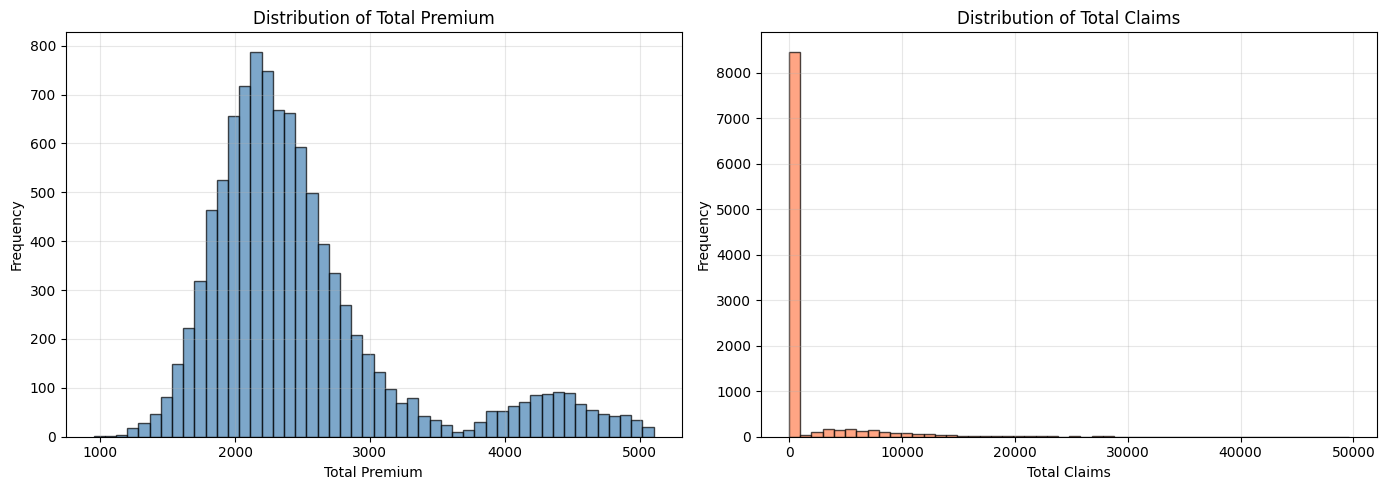

TotalPremium - Skewness: 1.58
TotalClaims - Skewness: 4.37


In [9]:
# Create histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TotalPremium distribution
axes[0].hist(df['TotalPremium'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Total Premium')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Total Premium')
axes[0].grid(True, alpha=0.3)

# TotalClaims distribution
axes[1].hist(df['TotalClaims'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Total Claims')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Total Claims')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"TotalPremium - Skewness: {df['TotalPremium'].skew():.2f}")
print(f"TotalClaims - Skewness: {df['TotalClaims'].skew():.2f}")

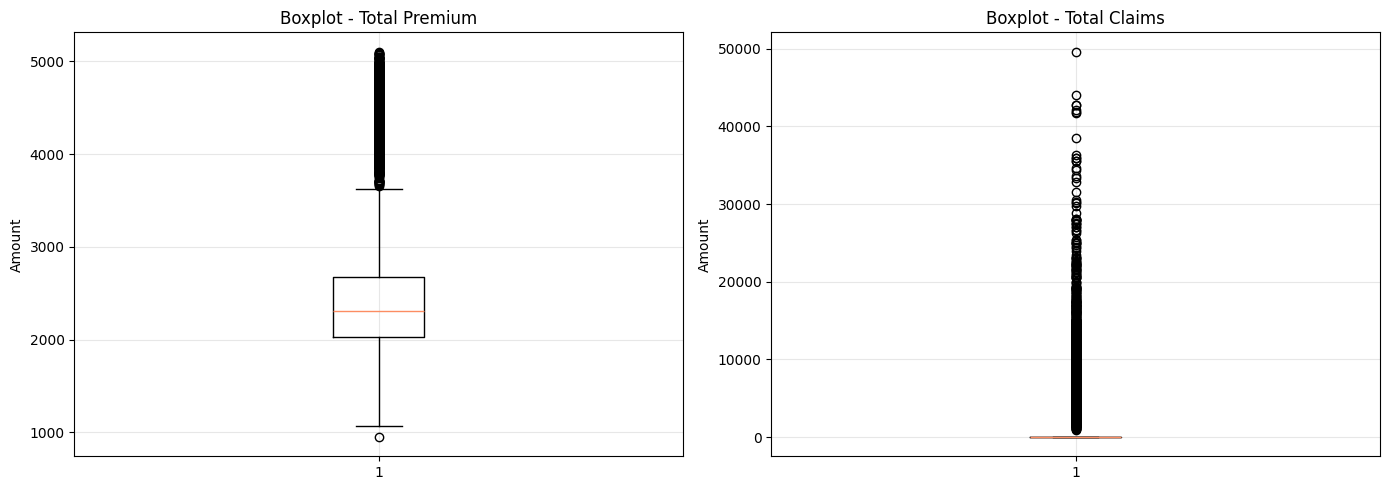

Outliers in TotalPremium: 950
Outliers in TotalClaims: 1535


In [10]:
# Boxplots for outlier detection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TotalPremium boxplot
axes[0].boxplot(df['TotalPremium'].dropna())
axes[0].set_title('Boxplot - Total Premium')
axes[0].set_ylabel('Amount')
axes[0].grid(True, alpha=0.3)

# TotalClaims boxplot
axes[1].boxplot(df['TotalClaims'].dropna())
axes[1].set_title('Boxplot - Total Claims')
axes[1].set_ylabel('Amount')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Count outliers using IQR method
Q1 = df['TotalPremium'].quantile(0.25)
Q3 = df['TotalPremium'].quantile(0.75)
IQR = Q3 - Q1
outliers_premium = ((df['TotalPremium'] < (Q1 - 1.5 * IQR)) | (df['TotalPremium'] > (Q3 + 1.5 * IQR))).sum()

Q1 = df['TotalClaims'].quantile(0.25)
Q3 = df['TotalClaims'].quantile(0.75)
IQR = Q3 - Q1
outliers_claims = ((df['TotalClaims'] < (Q1 - 1.5 * IQR)) | (df['TotalClaims'] > (Q3 + 1.5 * IQR))).sum()

print(f"Outliers in TotalPremium: {outliers_premium}")
print(f"Outliers in TotalClaims: {outliers_claims}")

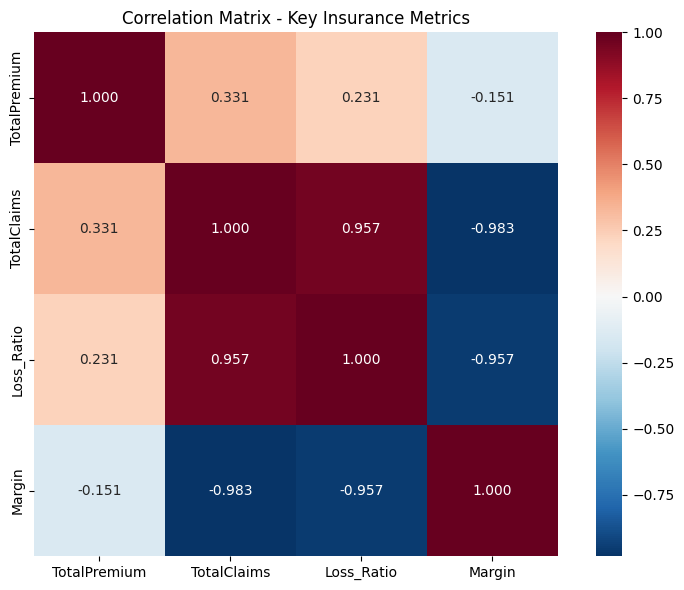

CORRELATION INTERPRETATION
TotalPremium vs TotalClaims correlation: The relationship between what customers pay and what the company pays out.


In [11]:
# Correlation matrix
corr_cols = ['TotalPremium', 'TotalClaims', 'Loss_Ratio', 'Margin']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, square=True, fmt='.3f')
plt.title('Correlation Matrix - Key Insurance Metrics')
plt.tight_layout()
plt.show()

print("="*60)
print("CORRELATION INTERPRETATION")
print("="*60)
print("TotalPremium vs TotalClaims correlation: The relationship between what customers pay and what the company pays out.")

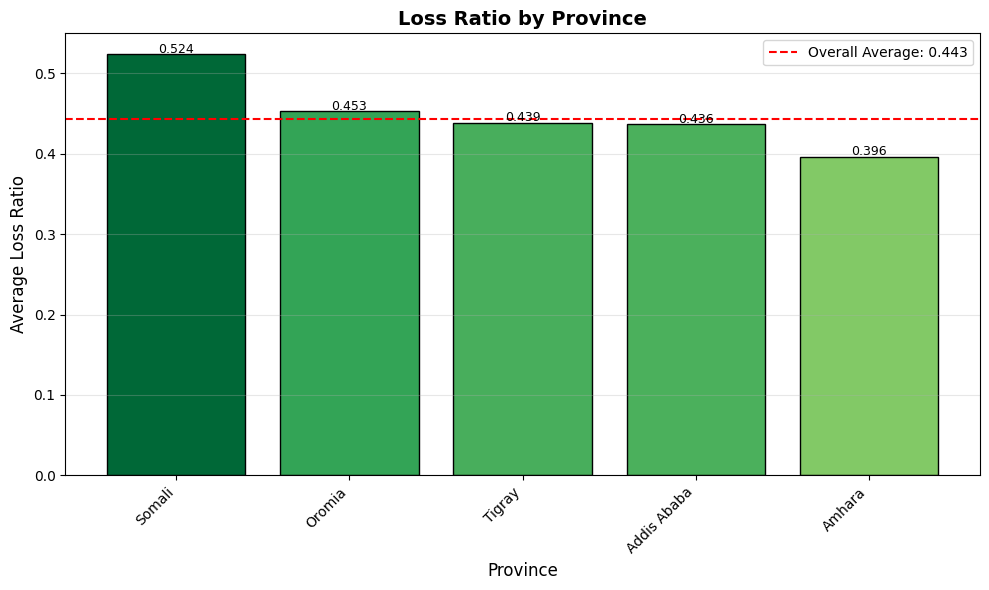

In [12]:
# Loss Ratio by Province - Bar Chart
province_loss = df.groupby('Province')['Loss_Ratio'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(province_loss.values / province_loss.max())
bars = plt.bar(province_loss.index, province_loss.values, color=colors, edgecolor='black')
plt.axhline(y=df['Loss_Ratio'].mean(), color='red', linestyle='--', label=f'Overall Average: {df["Loss_Ratio"].mean():.3f}')
plt.xlabel('Province', fontsize=12)
plt.ylabel('Average Loss Ratio', fontsize=12)
plt.title('Loss Ratio by Province', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, province_loss.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f'{value:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

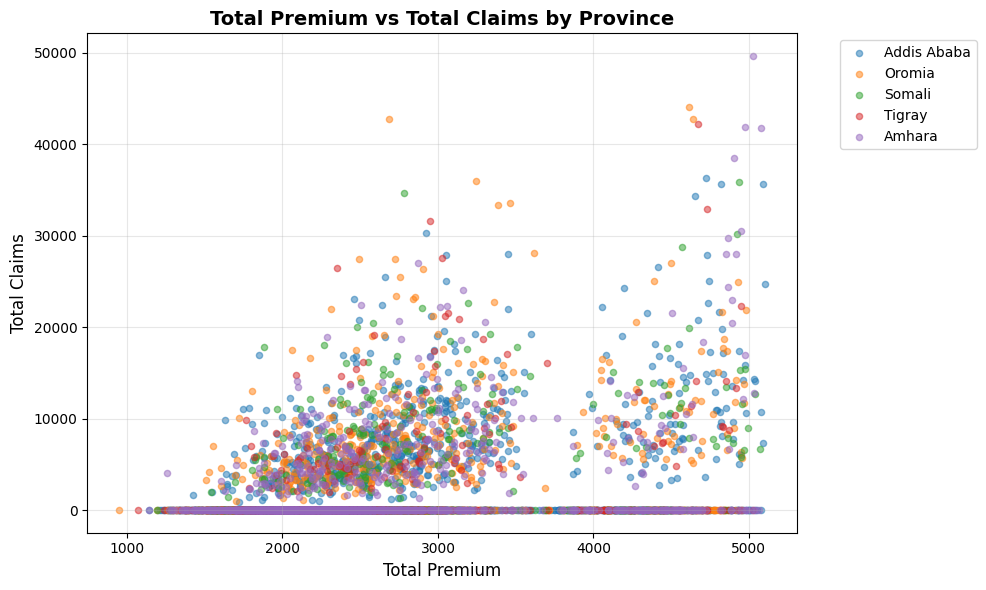

Correlation between TotalPremium and TotalClaims: 0.331


In [13]:
# Scatter plot: TotalPremium vs TotalClaims
plt.figure(figsize=(10, 6))

# Color by Province
provinces = df['Province'].unique()
colors = plt.cm.tab10(range(len(provinces)))

for i, province in enumerate(provinces):
    subset = df[df['Province'] == province]
    plt.scatter(subset['TotalPremium'], subset['TotalClaims'], 
                alpha=0.5, label=province, color=colors[i], s=20)

plt.xlabel('Total Premium', fontsize=12)
plt.ylabel('Total Claims', fontsize=12)
plt.title('Total Premium vs Total Claims by Province', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation
correlation = df['TotalPremium'].corr(df['TotalClaims'])
print(f"Correlation between TotalPremium and TotalClaims: {correlation:.3f}")

In [15]:
# Check all column names
print("All columns in dataset:")
print(df.columns.tolist())

All columns in dataset:
['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode', 'TransactionDate', 'Loss_Ratio', 'Margin']


Available categorical columns: ['VehicleType', 'CoverType', 'Province', 'Gender']

Analyzing by: VehicleType


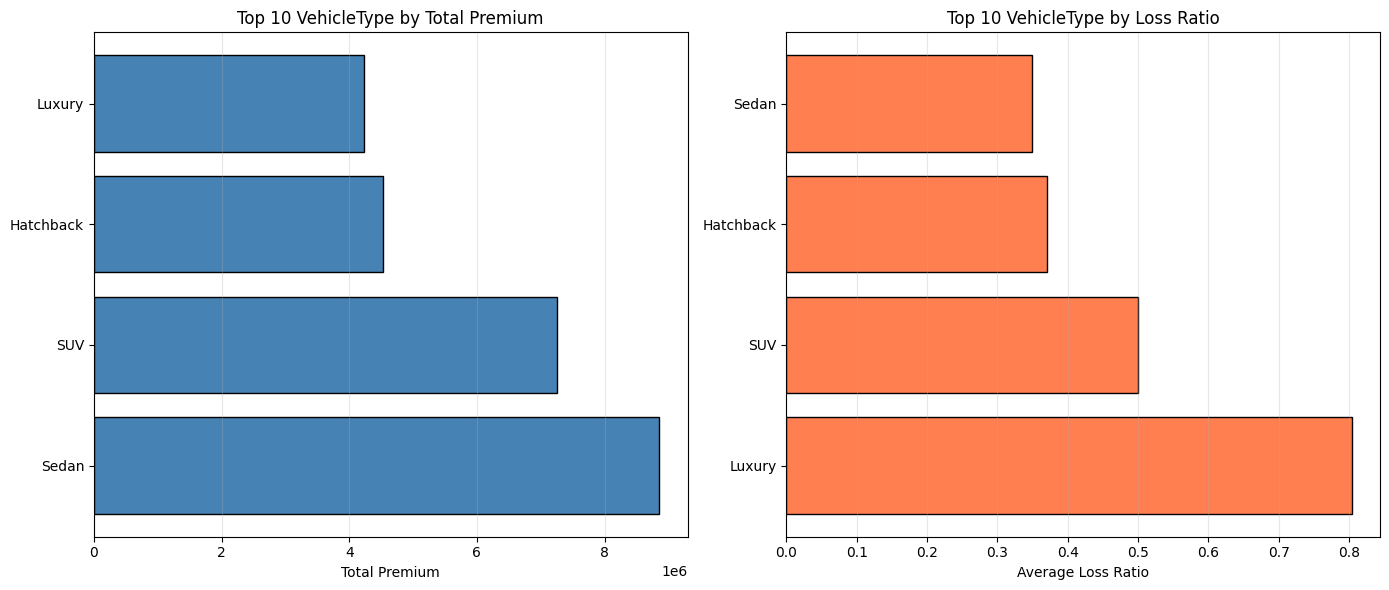

In [16]:
# Find categorical columns that exist
categorical_cols = []
for col in ['Make', 'Model', 'VehicleType', 'CoverType', 'Province', 'Gender']:
    if col in df.columns:
        categorical_cols.append(col)

print(f"Available categorical columns: {categorical_cols}")

if categorical_cols:
    # Use first available categorical column for analysis
    cat_col = categorical_cols[0]
    print(f"\nAnalyzing by: {cat_col}")
    
    # Top categories by TotalPremium
    top_cats = df.groupby(cat_col)['TotalPremium'].sum().sort_values(ascending=False).head(10)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Total Premium by Category
    axes[0].barh(range(len(top_cats)), top_cats.values, color='steelblue', edgecolor='black')
    axes[0].set_yticks(range(len(top_cats)))
    axes[0].set_yticklabels(top_cats.index)
    axes[0].set_xlabel('Total Premium')
    axes[0].set_title(f'Top 10 {cat_col} by Total Premium')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Loss Ratio by Category
    cat_loss = df.groupby(cat_col)['Loss_Ratio'].mean().sort_values(ascending=False).head(10)
    axes[1].barh(range(len(cat_loss)), cat_loss.values, color='coral', edgecolor='black')
    axes[1].set_yticks(range(len(cat_loss)))
    axes[1].set_yticklabels(cat_loss.index)
    axes[1].set_xlabel('Average Loss Ratio')
    axes[1].set_title(f'Top 10 {cat_col} by Loss Ratio')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found for analysis")

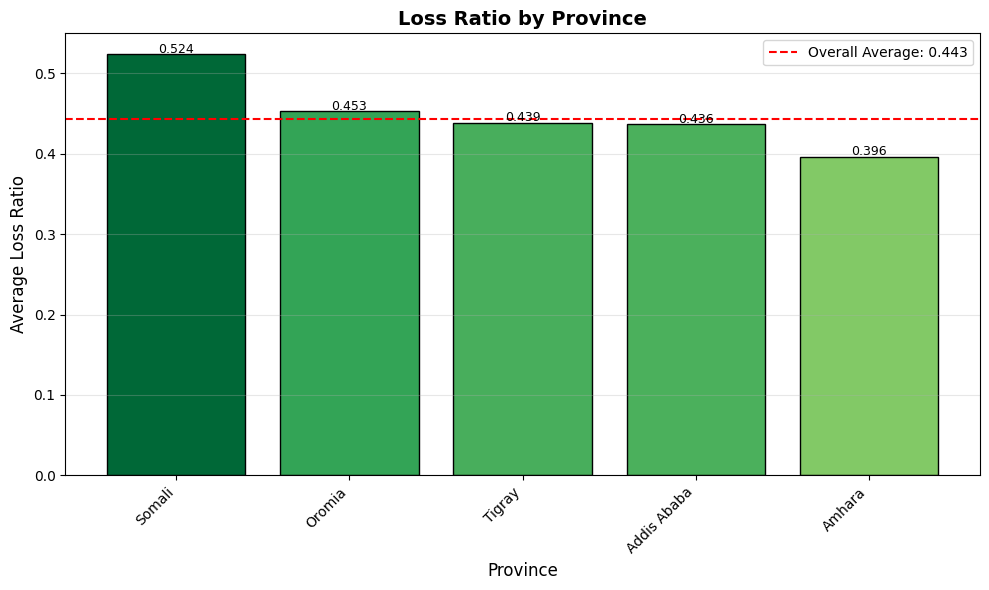

In [17]:
# Loss Ratio by Province - Bar Chart
province_loss = df.groupby('Province')['Loss_Ratio'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(province_loss.values / province_loss.max())
bars = plt.bar(province_loss.index, province_loss.values, color=colors, edgecolor='black')
plt.axhline(y=df['Loss_Ratio'].mean(), color='red', linestyle='--', label=f'Overall Average: {df["Loss_Ratio"].mean():.3f}')
plt.xlabel('Province', fontsize=12)
plt.ylabel('Average Loss Ratio', fontsize=12)
plt.title('Loss Ratio by Province', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, province_loss.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f'{value:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

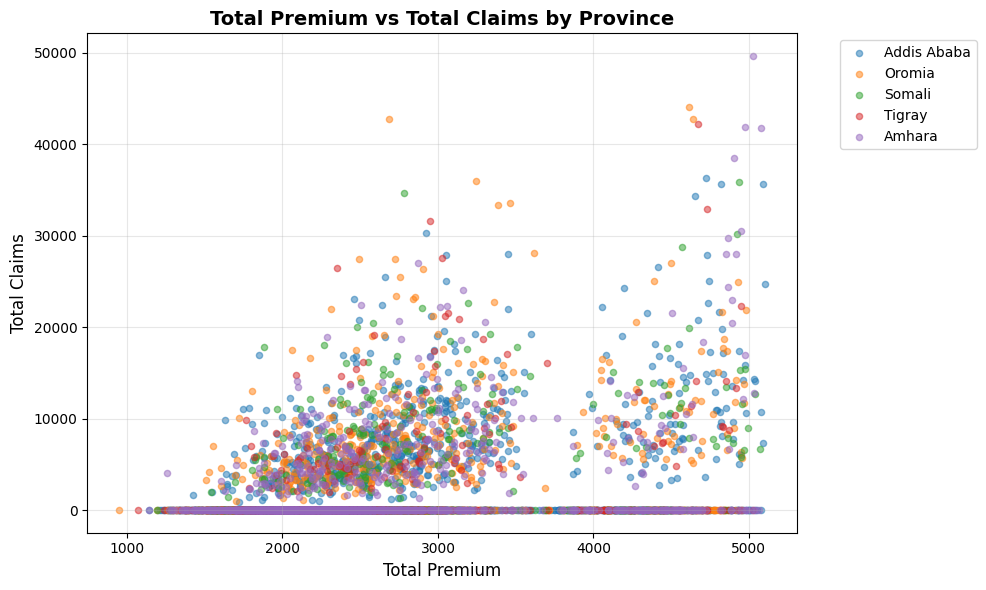

Correlation between TotalPremium and TotalClaims: 0.331


In [18]:
# Scatter plot: TotalPremium vs TotalClaims
plt.figure(figsize=(10, 6))

# Color by Province
provinces = df['Province'].unique()
colors = plt.cm.tab10(range(len(provinces)))

for i, province in enumerate(provinces):
    subset = df[df['Province'] == province]
    plt.scatter(subset['TotalPremium'], subset['TotalClaims'], 
                alpha=0.5, label=province, color=colors[i], s=20)

plt.xlabel('Total Premium', fontsize=12)
plt.ylabel('Total Claims', fontsize=12)
plt.title('Total Premium vs Total Claims by Province', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation
correlation = df['TotalPremium'].corr(df['TotalClaims'])
print(f"Correlation between TotalPremium and TotalClaims: {correlation:.3f}")

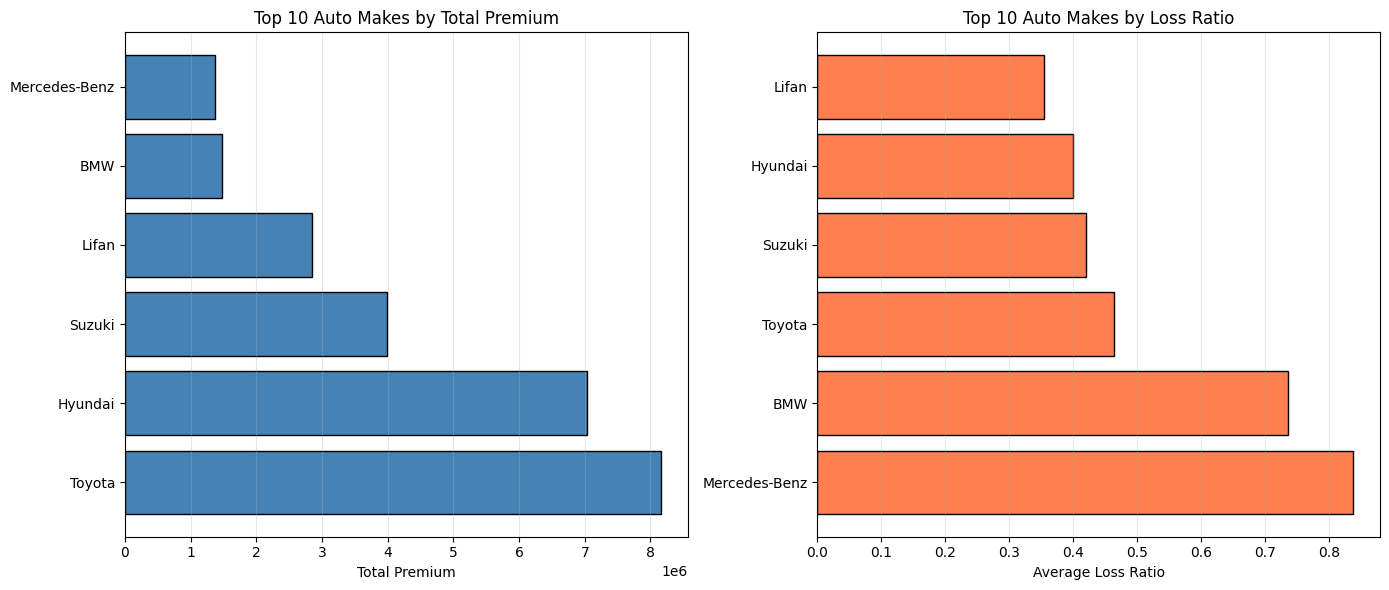

In [19]:
# Top 10 Auto Makes by TotalPremium
top_makes = df.groupby('AutoMake')['TotalPremium'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total Premium by AutoMake
axes[0].barh(top_makes.index, top_makes.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Total Premium')
axes[0].set_title('Top 10 Auto Makes by Total Premium')
axes[0].grid(axis='x', alpha=0.3)

# Loss Ratio by AutoMake
make_loss = df.groupby('AutoMake')['Loss_Ratio'].mean().sort_values(ascending=False).head(10)
axes[1].barh(make_loss.index, make_loss.values, color='coral', edgecolor='black')
axes[1].set_xlabel('Average Loss Ratio')
axes[1].set_title('Top 10 Auto Makes by Loss Ratio')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

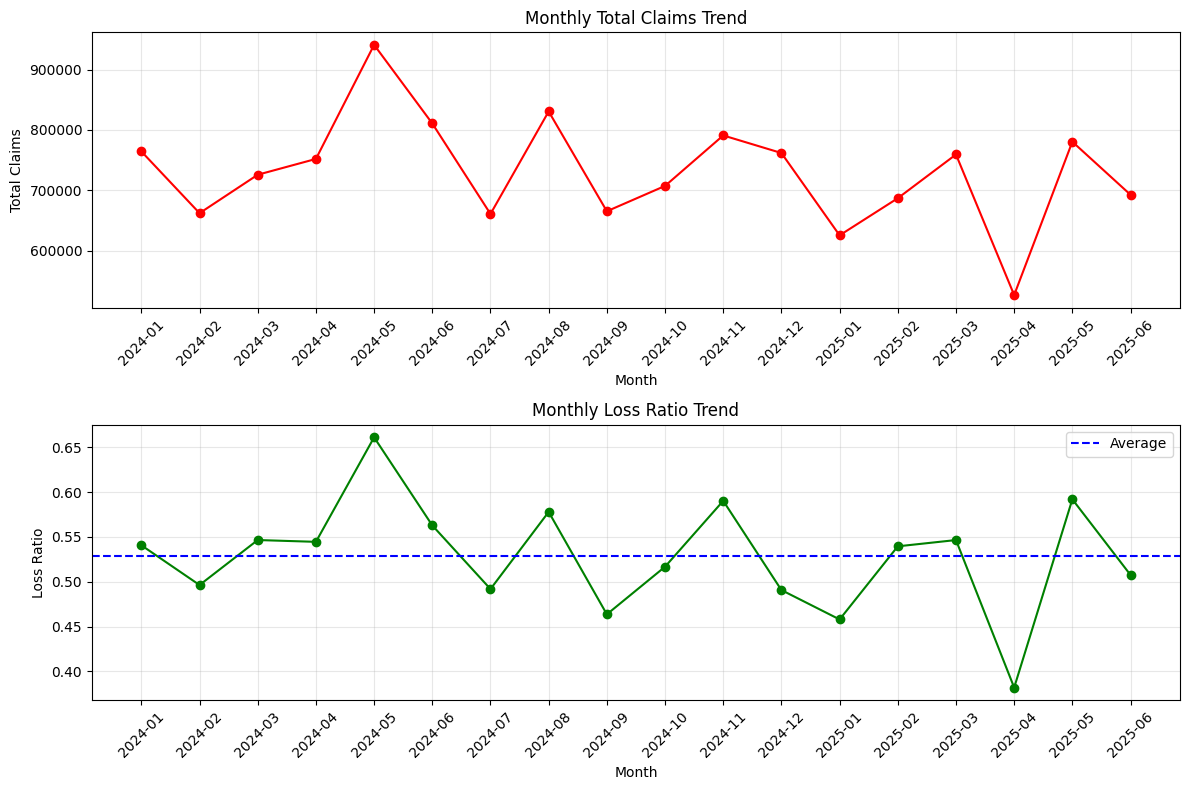

In [20]:
# Convert TransactionDate to datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# Extract month and year
df['YearMonth'] = df['TransactionDate'].dt.to_period('M')

# Aggregate by month
monthly_claims = df.groupby('YearMonth')['TotalClaims'].sum()
monthly_premium = df.groupby('YearMonth')['TotalPremium'].sum()
monthly_loss_ratio = monthly_claims / monthly_premium

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(monthly_claims.index.astype(str), monthly_claims.values, marker='o', color='red')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Claims')
axes[0].set_title('Monthly Total Claims Trend')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_loss_ratio.index.astype(str), monthly_loss_ratio.values, marker='o', color='green')
axes[1].axhline(y=monthly_loss_ratio.mean(), color='blue', linestyle='--', label='Average')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Loss Ratio')
axes[1].set_title('Monthly Loss Ratio Trend')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [21]:
# Compare metrics by Gender
print("="*60)
print("METRICS BY GENDER")
print("="*60)

gender_summary = df.groupby('Gender').agg({
    'TotalPremium': ['mean', 'sum'],
    'TotalClaims': ['mean', 'sum'],
    'Loss_Ratio': 'mean'
}).round(2)

print(gender_summary)

# Compare by VehicleType
print("\n" + "="*60)
print("METRICS BY VEHICLE TYPE")
print("="*60)

vehicle_summary = df.groupby('VehicleType').agg({
    'TotalPremium': ['mean', 'sum'],
    'TotalClaims': ['mean', 'sum'],
    'Loss_Ratio': 'mean'
}).round(2)

print(vehicle_summary)

METRICS BY GENDER
       TotalPremium           TotalClaims            Loss_Ratio
               mean       sum        mean        sum       mean
Gender                                                         
Female      2489.52  12791141     1316.28  6763030.0       0.45
Male        2486.66  12090138     1311.98  6378855.0       0.44

METRICS BY VEHICLE TYPE
            TotalPremium          TotalClaims            Loss_Ratio
                    mean      sum        mean        sum       mean
VehicleType                                                        
Hatchback        2226.00  4532134      935.28  1904235.0       0.37
Luxury           4358.89  4236839     3672.02  3569207.0       0.80
SUV              2418.81  7256436     1363.56  4090665.0       0.50
Sedan            2218.40  8855870      896.24  3577778.0       0.35


AGE AND RISK ANALYSIS
          RiskScore  TotalPremium  Loss_Ratio
AgeGroup                                     
18-25         73.89       2942.36        1.33
26-35         53.96       2364.95        0.47
36-50         53.19       2329.67        0.29
51-65         53.79       2366.24        0.22
65+           63.54       2662.34        0.29


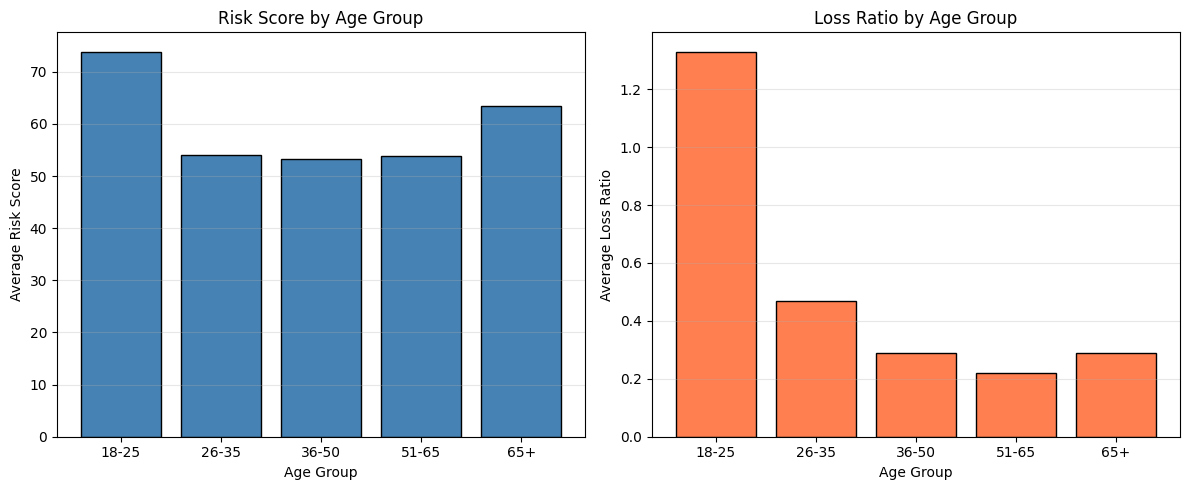

In [22]:
# Age distribution and RiskScore
print("="*60)
print("AGE AND RISK ANALYSIS")
print("="*60)

# Age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 50, 65, 100], 
                         labels=['18-25', '26-35', '36-50', '51-65', '65+'])

age_risk = df.groupby('AgeGroup').agg({
    'RiskScore': 'mean',
    'TotalPremium': 'mean',
    'Loss_Ratio': 'mean'
}).round(2)

print(age_risk)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RiskScore by Age Group
axes[0].bar(age_risk.index, age_risk['RiskScore'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Average Risk Score')
axes[0].set_title('Risk Score by Age Group')
axes[0].grid(axis='y', alpha=0.3)

# Loss Ratio by Age Group
axes[1].bar(age_risk.index, age_risk['Loss_Ratio'], color='coral', edgecolor='black')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Loss Ratio')
axes[1].set_title('Loss Ratio by Age Group')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
print("="*60)
print("KEY EDA INSIGHTS SUMMARY")
print("="*60)

print("\n1. OVERALL PORTFOLIO METRICS:")
print(f"   - Total Premium: {df['TotalPremium'].sum():,.2f}")
print(f"   - Total Claims: {df['TotalClaims'].sum():,.2f}")
print(f"   - Overall Loss Ratio: {(df['TotalClaims'].sum() / df['TotalPremium'].sum()) * 100:.2f}%")
print(f"   - Overall Margin: {df['Margin'].sum():,.2f}")

print("\n2. PROVINCE WITH HIGHEST LOSS RATIO:")
highest_province = province_loss.index[0]
print(f"   - {highest_province}: {province_loss.iloc[0]:.4f}")

print("\n3. PROVINCE WITH LOWEST LOSS RATIO:")
lowest_province = province_loss.index[-1]
print(f"   - {lowest_province}: {province_loss.iloc[-1]:.4f}")

print("\n4. GENDER COMPARISON:")
if 'Gender' in df.columns:
    gender_loss = df.groupby('Gender')['Loss_Ratio'].mean()
    for gender, loss in gender_loss.items():
        print(f"   - {gender}: {loss:.4f}")

print("\n5. VEHICLE TYPE WITH HIGHEST LOSS RATIO:")
if 'VehicleType' in df.columns:
    vehicle_loss = df.groupby('VehicleType')['Loss_Ratio'].mean().sort_values(ascending=False)
    print(f"   - {vehicle_loss.index[0]}: {vehicle_loss.iloc[0]:.4f}")

print("\n6. CORRELATION:")
print(f"   - Premium vs Claims: {correlation:.3f}")

KEY EDA INSIGHTS SUMMARY

1. OVERALL PORTFOLIO METRICS:
   - Total Premium: 24,881,279.00
   - Total Claims: 13,141,885.00
   - Overall Loss Ratio: 52.82%
   - Overall Margin: 11,739,394.00

2. PROVINCE WITH HIGHEST LOSS RATIO:
   - Somali: 0.5235

3. PROVINCE WITH LOWEST LOSS RATIO:
   - Amhara: 0.3959

4. GENDER COMPARISON:
   - Female: 0.4474
   - Male: 0.4379

5. VEHICLE TYPE WITH HIGHEST LOSS RATIO:
   - Luxury: 0.8037

6. CORRELATION:
   - Premium vs Claims: 0.331


In [24]:
# Save the processed data for Task 2
df.to_csv('data/insurance_data_cleaned.csv', index=False)
print("✅ Cleaned data saved to: data/insurance_data_cleaned.csv")
print(f"   Shape: {df.shape}")

✅ Cleaned data saved to: data/insurance_data_cleaned.csv
   Shape: (10000, 25)
